# Simple Linear Regression in Python

Last Updated: 23 Jul, 2025

Simple linear regression models the relationship between a dependent variable and a single independent variable. In this article, we will explore simple linear regression and its implementation in Python using libraries such as NumPy, Pandas, and scikit-learn.

## Understanding Simple Linear Regression

Simple Linear Regression aims to describe how one variable i.e., the dependent variable changes in relation with reference to the independent variable. For example, consider a scenario where a company wants to predict sales based on advertising expenditure. By using simple linear regression, the company can determine if an increase in advertising leads to higher sales or not.

The below graph explains the relationship between advertising expenditure and sales using simple linear regression:

![Simple Linear Regression](img/1.png)

The relationship between the dependent and independent variables is represented by the simple linear equation:

$$y = mx + b$$

Here:
- $y$ is the predicted value (dependent variable)
- $m$ is the slope of the line
- $x$ is the independent variable
- $b$ is the y-intercept (the value of $y$ when $x$ is 0)

In this equation $m$ signifies the slope of the line indicating how much $y$ changes for a one-unit increase in $x$. A positive $m$ suggests a direct relationship while a negative $m$ indicates an inverse relationship.

## Statistical Representation

To better understand this relationship we can express it in a more statistical context using the linear regression formula:

$$Y = \beta_0 + \beta_1 x$$

In simple linear regression, the parameters $\beta_0$ and $\beta_1$ play crucial roles in defining the relationship between the independent variable $X$ and the dependent variable $Y$ in the regression equation.

### Intercept $\beta_0$

The intercept $\beta_0$ represents the predicted value of the dependent variable $Y$ when the independent variable $X$ is zero. In other words, it is the point where the regression line crosses the y-axis.

It provides a baseline value for $Y$ and helps us understand the expected outcome when there is no influence from $X$. For example, if you were predicting sales based on advertising expenditure, $\beta_0$ would indicate the estimated sales when no money is spent on advertising.

![Intercept](img/2.png)

### Slope $\beta_1$

The slope $\beta_1$ represents the change in the dependent variable $Y$ for a one-unit increase in the independent variable $X$. It quantifies the strength and direction of the relationship between $X$ and $Y$:

- A **positive** $\beta_1$ value suggests that as $X$ increases, $Y$ also increases, indicating a direct relationship.
- Conversely, a **negative** $\beta_1$ value indicates that an increase in $X$ leads to a decrease in $Y$, indicating an inverse relationship.

For instance, if $\beta_1 = 2$, this would mean that for every additional unit spent on advertising, sales are expected to increase by 2 units.

![Slope](img/3.png)

---

## Implementing Simple Linear Regression in Python

In order to use Simple Linear Regression in Python we must first install Python and a few necessary libraries.

We will use an actual dataset to demonstrate how to use basic linear regression. We'll be using the Boston Housing Dataset. This dataset provides details on Boston real estate costs as well as room counts, crime rates and other attributes. Based on the number of rooms we will forecast the cost of the house.

### Step 1: Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

`train_test_split` is a function from the `sklearn.model_selection` module that is used to divide a dataset into two subsets: a training set and a testing set.

-   **Training Set**: This subset is used to train the machine learning model. The model learns the underlying patterns and relationships from this data.
-   **Testing Set**: This subset is used to evaluate the performance of the trained model on unseen data. By testing the model on data it hasn't seen before, we can get a more accurate assessment of its generalization capability and identify potential issues like overfitting.

This splitting process is crucial for assessing how well a model will perform on new, real-world data and helps in preventing the model from memorizing the training data instead of learning general patterns. Common parameters include `test_size` (to specify the proportion of the dataset to include in the test split) and `random_state` (for reproducibility).

### Step 2: Load and Explore the Dataset

We will load the dataset from the CSV file, check its structure, and examine a few sample records.

In [3]:
# Load the Boston Housing dataset from CSV
# Use sep='\s+' to correctly parse the space-separated values
df = pd.read_csv("housing.csv", sep='\s+')
print(df.head())

# Define the proper column names for the Boston Housing dataset
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE']

# Assign column names to the dataframe
df.columns = column_names

# Display the first few rows of the dataset
print(df.head())

# Check for missing values
print(df.isnull().sum())

   0.00632  18.00  2.310  0  0.5380  6.5750  65.20  4.0900  1  296.0  15.30  \
0  0.02731    0.0   7.07  0   0.469   6.421   78.9  4.9671  2  242.0   17.8   
1  0.02729    0.0   7.07  0   0.469   7.185   61.1  4.9671  2  242.0   17.8   
2  0.03237    0.0   2.18  0   0.458   6.998   45.8  6.0622  3  222.0   18.7   
3  0.06905    0.0   2.18  0   0.458   7.147   54.2  6.0622  3  222.0   18.7   
4  0.02985    0.0   2.18  0   0.458   6.430   58.7  6.0622  3  222.0   18.7   

   396.90  4.98  24.00  
0  396.90  9.14   21.6  
1  392.83  4.03   34.7  
2  394.63  2.94   33.4  
3  396.90  5.33   36.2  
4  394.12  5.21   28.7  
      CRIM   ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  PTRATIO  \
0  0.02731  0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0     17.8   
1  0.02729  0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0     17.8   
2  0.03237  0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0     18.7   
3  0.06905  0.0   2.18     0  0.458  7.147  54.2  6

In this dataset:

- **CRIM**: per capita crime rate by town
- **ZN**: proportion of residential land zoned for lots over 25,000 sq. ft.
- **RM**: average number of rooms per dwelling
- **PRICE**: median value of owner-occupied homes in $1000s (this is our target variable)

### <br>Step 3: Selecting Features and Splitting the Data

In [4]:
# Define the feature (independent variable) and target (dependent variable)
X = df[["RM"]]     # Number of rooms
Y = df["PRICE"]    # House prices

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 404
Testing set size: 101


### <br>Step 4: Train the Simple Linear Regression Model
Now we can create a Linear Regression model using scikit-learn and train it on the training data. 
The model will calculate the intercept (𝛽0) and coefficient (𝛽1) of the linear equation.

In [5]:
# Create a Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, Y_train)

# Print the intercept and coefficient
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_}")

Intercept: -36.686319017419066
Coefficient: [9.43524424]


### <br>Step 5: Make Predictions
Once the model is trained, we can use it to make predictions on the test data.

In [6]:
# Predict house prices for the test set
Y_predict = model.predict(X_test)

# Display the first few predictions alongside the actual values
predictions = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_predict})
predictions.head()

,Actual,Predicted
173,22.6,18.594777
274,32.0,27.982845
490,13.6,19.764747
72,23.4,22.236781
305,33.4,33.323193


### <br>Step 6: Visualize the Regression Line
A good way to understand the relationship between the predicted and actual data is to visualize it. 
We'll plot the regression line along with the actual data points.

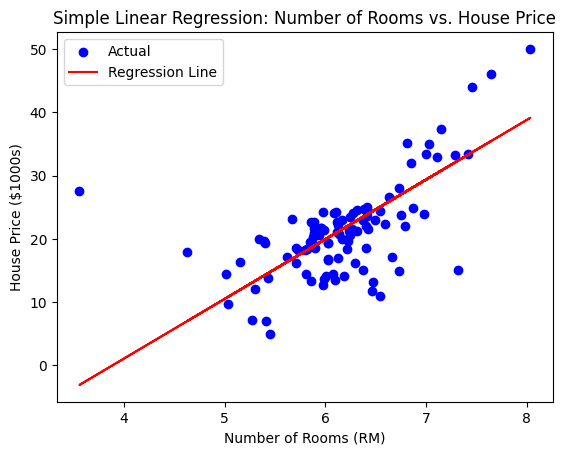

In [7]:
# Plot the actual data points
plt.scatter(X_test, Y_test, color='blue', label='Actual')

# Plot the regression line
plt.plot(X_test, Y_predict, color='red', label='Regression Line')

# Add labels and title
plt.xlabel('Number of Rooms (RM)')
plt.ylabel('House Price ($1000s)')
plt.title('Simple Linear Regression: Number of Rooms vs. House Price')
plt.legend()
plt.show()

### <br>Step 7: Evaluate the Model
Finally, we will evaluate the model's performance using metrics such as Mean Squared Error (MSE) and R-squared score.

In [ ]:
import math

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(Y_test, Y_predict)
print(f"Mean Squared Error: {mse}")
print("RMSE: ", math.sqrt(mse))

# Calculate R-squared score
r2 = r2_score(Y_test, Y_predict)
print(f"R-squared score: {r2}")


Mean Squared Error: 36.34645904214551
RMSE:  6.028802455060665
R-squared score: 0.34771980794659596
